# 07. CatBoost Ranker & Offline Model Comparison (A/B Test)
 
 Notebook này xây dựng mô hình xếp hạng chi tiết thứ hai dùng giải thuật **CatBoost Ranker (YetiRank)**, tiến hành so sánh trực tiếp hiệu năng ngoại tuyến với **LightGBM LambdaRank** trên cùng tập dữ liệu kiểm thử, đo lường tốc độ suy luận và phân tích độ quan trọng của đặc trưng (Feature Importance).
 
 ---
 
 ### Tại sao YetiRank của CatBoost lại mạnh cho bài toán Ranking?
 *   **YetiRank** không tối ưu hóa các mẫu nhị phân độc lập mà tối ưu hóa phân phối xếp hạng toàn cục dựa trên các hoán vị (permutations). Nó tránh được hiện tượng chệch gradient (gradient bias) bằng cách ước tính kỳ vọng của sự thay đổi chỉ số NDCG khi hoán đổi vị trí của các cặp vật phẩm.
 *   **Oblivious Trees**: CatBoost sử dụng cấu trúc cây đối xứng giúp hạn chế overfitting tốt trên các tập dữ liệu nhỏ.
 

### Bước 1: Khởi tạo và Tải thư viện
Tế bào này nạp các thư viện, tự động cài đặt gói `catboost` nếu chưa có trên hệ thống, tải dữ liệu train ratings và các mô hình Retrieval Stage 1 để làm đặc trưng huấn luyện.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import pickle
import time
import matplotlib.pyplot as plt
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

# Thêm đường dẫn cha để import recsys_utils
sys.path.append(os.path.abspath('..'))
from recsys_utils import evaluate_implicit_loo, calculate_beyond_accuracy_metrics, BM25

# Cài đặt catboost nếu chưa có
try:
    from catboost import CatBoostRanker, Pool
except ImportError:
    print("Installing catboost...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost"])
    from catboost import CatBoostRanker, Pool

# Load dữ liệu đã xử lý
train_ratings = pd.read_csv("processed_data/train_ratings.csv")
movies_df = pd.read_csv(os.path.join("..", "..", "data", "crawler", "movies_crawled.csv"))
users_df = pd.read_csv(os.path.join("..", "..", "data", "simulator", "sim_users.csv"))

with open("processed_data/id_mappings.pkl", "rb") as f:
    user_to_idx, movie_to_idx, idx_to_movie = pickle.load(f)
    
with open("processed_data/user_interacted_items.pkl", "rb") as f:
    user_interacted_items = pickle.load(f)

# Load retrieval models/matrices for feature engineering
with open("models/als_model.pkl", "rb") as f:
    als_model = pickle.load(f)
    
with open("models/bm25_model.pkl", "rb") as f:
    bm25 = pickle.load(f)

with open("processed_data/user_item_matrix.pkl", "rb") as f:
    user_item_matrix = pickle.load(f)


### Bước 2: Sinh Tập dữ liệu Huấn luyện (Negative Sampling)
Tương tự như khi huấn luyện LightGBM, tế bào này thực hiện lấy mẫu âm tỷ lệ 1:4 đối với mỗi tương tác dương thực tế để xây dựng tập dữ liệu train ratings cân bằng thông qua chiến lược **Hard Negatives (từ iALS)** kết hợp **Random Negatives**.


In [2]:
# 1. Tạo tập dữ liệu huấn luyện cho Ranker (giống LightGBM)
np.random.seed(42)

# Precompute iALS candidates cho mọi user trong train ratings phục vụ trích xuất hard negatives
print("Đang sinh danh sách hard negatives từ iALS...")
als_hard_candidates = {}
for u in train_ratings['userId'].unique():
    u_idx = user_to_idx.get(u, None)
    if u_idx is not None:
        ids, _ = als_model.recommend(u_idx, user_item_matrix[u_idx], N=200)
        movie_ids = [idx_to_movie[i] for i in ids if i in idx_to_movie]
        als_hard_candidates[u] = movie_ids

ranking_data = []
all_movie_ids = list(movie_to_idx.keys())

for _, row in train_ratings.iterrows():
    u = int(row['userId'])
    pos_item = int(row['movieId'])
    rating = row['rating']
    label = 1 if rating >= 3.5 else 0
    ranking_data.append({'userId': u, 'movieId': pos_item, 'label': label})
    
    interacted = user_interacted_items.get(u, set())
    hard_negs = als_hard_candidates.get(u, [])
    # Lọc bỏ các phim user đã tương tác
    hard_negs_clean = [m for m in hard_negs if m not in interacted]
    
    # Lấy mẫu tối đa 2 hard negatives
    num_hard_to_sample = min(2, len(hard_negs_clean))
    sampled_negs = []
    if num_hard_to_sample > 0:
        sampled_negs = list(np.random.choice(hard_negs_clean, size=num_hard_to_sample, replace=False))
        
    # Phần còn lại bù bằng random negatives
    num_rand_to_sample = 4 - len(sampled_negs)
    for _ in range(num_rand_to_sample):
        neg_item = np.random.choice(all_movie_ids)
        while neg_item in interacted or neg_item in sampled_negs:
            neg_item = np.random.choice(all_movie_ids)
        sampled_negs.append(neg_item)
        
    for neg_item in sampled_negs:
        ranking_data.append({'userId': u, 'movieId': neg_item, 'label': 0})

df_rank = pd.DataFrame(ranking_data)
# Đảm bảo df_rank được sắp xếp theo userId/group để làm ranking
df_rank_sorted = df_rank.sort_values(by='userId').reset_index(drop=True)


Đang sinh danh sách hard negatives từ iALS...


### Bước 3: Thiết kế Đặc trưng (Feature Engineering)
Tế bào này trích xuất các đặc trưng xếp hạng tương đồng với mô hình LightGBM bao gồm đặc trưng phim, đặc trưng user và các điểm số chéo (als_score, cb_score) để đảm bảo so sánh công bằng chéo (apples-to-apples comparison).


In [3]:
# 2. Xây dựng các đặc trưng (Feature Engineering)
movies_df['genres'] = movies_df['genres'].fillna('')
movies_df['director'] = movies_df['director'].fillna('')
movies_df['cast'] = movies_df['cast'].fillna('')
movies_df['keywords'] = movies_df['keywords'].fillna('')

def build_metadata_soup(row):
    genres = row['genres'].replace('|', ' ')
    cast = ' '.join(row['cast'].split('|')[:5])
    keywords = row['keywords'].replace('|', ' ')
    director = row['director'].replace(' ', '')
    return f"{genres} {director} {cast} {keywords}"

movies_df['soup'] = movies_df.apply(build_metadata_soup, axis=1)
movies_unindexed = movies_df.set_index('movieId', drop=False)
movies_df = movies_df.set_index('movieId')
users_df = users_df.set_index('user_id')

# Precompute user liked movie IDs to avoid slow dataframe scans in the loop
train_pos_ratings = train_ratings[train_ratings['rating'] >= 3.5]
user_liked_movies_dict = train_pos_ratings.groupby('userId')['movieId'].apply(list).to_dict()

# Precompute dictionary mappings for O(1) lookups (bypasses slow pandas .loc)
movie_popularity_dict = movies_df['popularity'].to_dict()
movie_vote_average_dict = movies_df['vote_average'].to_dict()
movie_genres_dict = movies_df['genres'].to_dict()
movie_genres_sets = {mid: set(str(g).split('|')) for mid, g in movie_genres_dict.items()}
movie_release_date_dict = movies_df['release_date'].to_dict()
movies_soup_dict = movies_unindexed['soup'].to_dict()

user_activity_dict = users_df['activity_level'].to_dict()
user_bias_dict = users_df['user_bias'].to_dict()

# Precompute user favorite genres from their actual watched history (rating >= 3.5) with fallback to seed list
user_fav_genres_dict = {}
for uid, fav_m_str in zip(users_df.index, users_df['favorite_movies']):
    liked_mids = user_liked_movies_dict.get(uid, [])
    genres = set()
    for lmid in liked_mids:
        g_str = movie_genres_dict.get(lmid)
        if g_str and g_str != "(no genres listed)":
            genres.update(g_str.split("|"))
            
    if not genres and pd.notna(fav_m_str):
        for m in str(fav_m_str).split("|"):
            if m.isdigit():
                fid = int(m)
                g_str = movie_genres_dict.get(fid)
                if g_str and g_str != "(no genres listed)":
                    genres.update(g_str.split("|"))
    user_fav_genres_dict[uid] = genres

uids = df_rank_sorted['userId'].values
mids = df_rank_sorted['movieId'].values

# Vectorized/fast lookup arrays
popularity_vec = [movie_popularity_dict.get(mid, 1.0) for mid in mids]
vote_average_vec = [movie_vote_average_dict.get(mid, 5.0) for mid in mids]
user_activity_vec = [user_activity_dict.get(uid, 15) for uid in uids]
user_bias_vec = [user_bias_dict.get(uid, 0.0) for uid in uids]

genre_overlaps = []
for uid, mid in zip(uids, mids):
    user_favs = user_fav_genres_dict.get(uid, set())
    m_genres = movie_genres_sets.get(mid, set())
    genre_overlaps.append(len(user_favs.intersection(m_genres)))

release_years = []
for mid in mids:
    try:
        release_years.append(int(str(movie_release_date_dict.get(mid, "2010"))[:4]))
    except:
        release_years.append(2010)

# Vectorized ALS scores (avoid loop row-by-row matrix multiplication)
u_idx_arr = np.array([user_to_idx.get(u, -1) for u in uids])
m_idx_arr = np.array([movie_to_idx.get(m, -1) for m in mids])
valid_mask = (u_idx_arr != -1) & (m_idx_arr != -1)
als_scores = np.zeros(len(df_rank_sorted))
if valid_mask.any():
    als_scores[valid_mask] = np.sum(
        als_model.user_factors[u_idx_arr[valid_mask]] * als_model.item_factors[m_idx_arr[valid_mask]], 
        axis=1
    )

# Fast CB scores using precomputed soup dictionary (avoid loc in loop)
cb_scores = []
current_uid = None
user_bm25_scores = None

for uid, mid in zip(uids, mids):
    m_idx = movie_to_idx.get(mid, None)
    if uid != current_uid:
        current_uid = uid
        liked_ids = user_liked_movies_dict.get(uid, [])
        liked_ids = [lid for lid in liked_ids if lid in movies_soup_dict]
        if liked_ids:
            liked_soups = [movies_soup_dict[lid] for lid in liked_ids]
            query = " ".join(liked_soups)
            user_bm25_scores = bm25.transform(query)
        else:
            user_bm25_scores = None
            
    cb_score = user_bm25_scores[m_idx] if (user_bm25_scores is not None and m_idx is not None) else 0.0
    cb_scores.append(cb_score)

# Instantly build features DataFrame
X_train = pd.DataFrame({
    'popularity': popularity_vec,
    'vote_average': vote_average_vec,
    'genre_overlap': genre_overlaps,
    'release_year': release_years,
    'user_activity': user_activity_vec,
    'user_bias': user_bias_vec,
    'als_score': als_scores,
    'cb_score': cb_scores
})
y_train = df_rank_sorted['label']
group_ids = df_rank_sorted['userId'].values # Mảng ID group cho CatBoost


### Bước 4: Huấn luyện mô hình xếp hạng CatBoost YetiRank

#### Nguyên lý giải thuật YetiRank:
**YetiRank** của CatBoost là một bước tiến vượt bậc so với LambdaRank. 
*   Thay vì chỉ nhân với lượng thay đổi NDCG cục bộ khi tráo đổi 2 phần tử, YetiRank tạo ra một chuỗi các hoán vị (permutations) giả định ngẫu nhiên đối với danh sách vật phẩm của mỗi người dùng.
*   Sau đó, YetiRank tối ưu hóa kỳ vọng toán học của độ chênh lệch chỉ số NDCG trên toàn bộ các hoán vị này. Điều này giúp CatBoost ước lượng chính xác hơn phân phối xếp hạng toàn cục và có xu hướng ổn định hơn khi phân phối dữ liệu huấn luyện nhỏ.
*   Đồng thời, cấu trúc cây đối xứng (Symmetric/Oblivious Trees) giúp việc đưa ra dự đoán của CatBoost rất nhanh vì có thể song song hóa tối đa ở mức phần cứng.

Tế bào này định nghĩa cấu trúc dữ liệu `Pool` của CatBoost, thiết lập hàm mất mát `loss_function='YetiRank'`, huấn luyện mô hình và lưu vào ổ đĩa.


In [4]:
# 3. Huấn luyện CatBoost Ranker (YetiRank)
train_pool = Pool(data=X_train, label=y_train, group_id=group_ids)

cat_ranker = CatBoostRanker(
    loss_function='YetiRank',
    iterations=200,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=50
)

start_time = time.time()
cat_ranker.fit(train_pool)
cat_train_time = time.time() - start_time
print(f"CatBoost trained in {cat_train_time:.2f} seconds.")

# Lưu mô hình
with open("models/cat_ranker.pkl", "wb") as f:
    pickle.dump(cat_ranker, f)


0:	total: 330ms	remaining: 1m 5s


50:	total: 7.95s	remaining: 23.2s


100:	total: 14.9s	remaining: 14.6s


150:	total: 21.8s	remaining: 7.08s


199:	total: 28.6s	remaining: 0us
CatBoost trained in 28.73 seconds.


### Bước 5: So sánh Tầm quan trọng của Đặc trưng (Feature Importance)
Tế bào này nạp mô hình LightGBM đã lưu, lấy mức độ đóng góp đặc trưng (Feature Importance) đã được chuẩn hóa của cả hai mô hình, vẽ biểu đồ so sánh trực tiếp để quan sát xem mỗi giải thuật ưu tiên những nhóm tín hiệu nào khi xếp hạng phim.


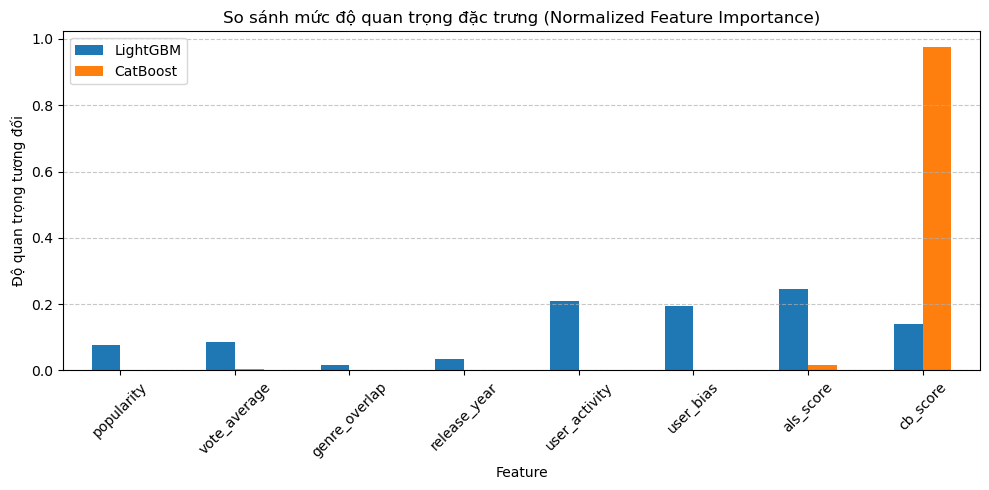

In [5]:
# 4. Trực quan hóa Feature Importance giữa CatBoost và LightGBM
# Load LightGBM model
with open("models/lgb_ranker.pkl", "rb") as f:
    lgb_ranker = pickle.load(f)

# Lấy tầm quan trọng đặc trưng
lgb_importances = lgb_ranker.feature_importances_
lgb_importances_norm = lgb_importances / lgb_importances.sum()

cat_importances = cat_ranker.get_feature_importance(train_pool)
cat_importances_norm = cat_importances / cat_importances.sum()

feature_names = X_train.columns

df_imp = pd.DataFrame({
    'Feature': feature_names,
    'LightGBM': lgb_importances_norm,
    'CatBoost': cat_importances_norm
}).set_index('Feature')

df_imp.plot(kind='bar', figsize=(10, 5))
plt.title("So sánh mức độ quan trọng đặc trưng (Normalized Feature Importance)")
plt.ylabel("Độ quan trọng tương đối")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [6]:
# 5. Định nghĩa Hàm Gợi ý E2E cho CatBoost
# Tải lại test_data
with open("processed_data/test_data.pkl", "rb") as f:
    test_data = pickle.load(f)
with open("processed_data/user_item_matrix.pkl", "rb") as f:
    user_item_matrix = pickle.load(f)

# Phục vụ tính lambda động
all_genres = sorted(list(set([g for genres in movies_df['genres'].str.split('|').dropna() for g in genres if g])))
movies_df_indexed = movies_df # index movieId đã có từ cell trước

# Trực quan hóa MMR TF-IDF
movies_df['mmr_soup'] = movies_df.apply(
    lambda r: f"{r['genres'].replace('|', ' ')} {r['director'].replace(' ', '')} {' '.join(r['cast'].split('|')[:3])}", 
    axis=1
)
from sklearn.feature_extraction.text import TfidfVectorizer
mmr_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = mmr_vectorizer.fit_transform(movies_df['mmr_soup'])

from recsys_utils import reciprocal_rank_fusion, calculate_user_lambda

def end_to_end_recommend_cat(user_id, top_k=10, eval_mode=False, eval_candidates=None):
    from recsys_utils import extract_user_features

    # --- EVAL MODE ---
    if eval_mode and eval_candidates is not None:
        X_pred, valid_mids = extract_user_features(
            user_id, eval_candidates, train_ratings, movies_df, users_df, 
            user_to_idx, movie_to_idx, als_model, bm25, is_train=False
        )
        if X_pred.empty:
            return [(mid, 0.0) for mid in eval_candidates]
        scores = cat_ranker.predict(X_pred)
        return list(zip(valid_mids, scores))

    # --- STAGE 1: RETRIEVAL (BM25 + iALS -> RRF) ---
    liked_movies = train_ratings[train_ratings['userId'] == user_id]['movieId'].tolist()
    liked_set = set(liked_movies)
    
    # A. BM25 content candidate retrieval (sử dụng tối đa 20 phim tương tác gần nhất hoặc favorite_movies nếu cold start)
    bm25_candidates = []
    if liked_movies:
        liked_movies_profile = liked_movies[-20:]
    else:
        # Cold start fallback: dùng danh sách phim yêu thích khởi tạo
        user = users_df.loc[user_id]
        fav_m_str = str(user.get("favorite_movies", ""))
        liked_movies_profile = [int(m) for m in fav_m_str.split("|") if str(m).isdigit()]
        
    liked_soups = [movies_df.loc[lid, 'soup'] for lid in liked_movies_profile if lid in movies_df.index]
    if liked_soups:
        query = " ".join(liked_soups)
        user_bm25_all_scores = bm25.transform(query)
        sorted_cb_idx = np.argsort(user_bm25_all_scores)[::-1]
        for idx in sorted_cb_idx:
            # Ở cell trước movies_df đã set_index('movieId'), dùng iloc và lấy chỉ mục movieId
            mid = movies_df.index[idx]
            if mid not in liked_set:
                bm25_candidates.append(mid)
            if len(bm25_candidates) >= 100:
                break
                
    # B. iALS collaborative candidate retrieval
    u_idx = user_to_idx.get(user_id, None)
    als_candidates = []
    if u_idx is not None:
        ids, _ = als_model.recommend(u_idx, user_item_matrix[u_idx], N=100)
        als_candidates = [idx_to_movie[i] for i in ids if i in idx_to_movie and idx_to_movie[i] not in liked_set]
        
    # C. Hợp nhất bằng RRF
    rrf_list = reciprocal_rank_fusion(als_candidates, bm25_candidates, k=60)
    candidates = [item[0] for item in rrf_list[:250]]
    
    if not candidates:
        candidates = movies_df.sort_values(by='popularity', ascending=False).index.head(100).tolist()
        candidates = [cid for cid in candidates if cid not in liked_set]
        
    # --- STAGE 2: RANKING (CatBoost) ---
    X_pred, valid_candidates = extract_user_features(
        user_id, candidates, train_ratings, movies_df, users_df, 
        user_to_idx, movie_to_idx, als_model, bm25, is_train=False
    )
    if X_pred.empty:
        return []
    
    scores = cat_ranker.predict(X_pred)
    
    candidate_scores = list(zip(valid_candidates, scores))
    candidate_scores.sort(key=lambda x: x[1], reverse=True)
    
    # --- STAGE 3: RE-RANKING (MMR với Lambda động) ---
    user_history_genres = []
    for hmid in liked_movies:
        if hmid in movies_df.index:
            user_history_genres.extend(str(movies_df.loc[hmid, 'genres']).split('|'))
    lambda_val = calculate_user_lambda(user_history_genres, all_genres, base_min=0.4, base_max=0.9)
    
    from sklearn.metrics.pairwise import cosine_similarity
    
    final_recs = []
    if candidate_scores:
        candidates_ids = [item[0] for item in candidate_scores]
        scores_arr = np.array([item[1] for item in candidate_scores])
        
        if scores_arr.max() != scores_arr.min():
            scores_norm = (scores_arr - scores_arr.min()) / (scores_arr.max() - scores_arr.min())
        else:
            scores_norm = np.ones_like(scores_arr)
            
        selected_items = []
        unselected_indices = list(range(len(candidates_ids)))
        
        first_choice = np.argmax(scores_norm)
        selected_items.append(candidates_ids[first_choice])
        unselected_indices.remove(first_choice)
        
        while len(selected_items) < top_k and unselected_indices:
            selected_matrix_indices = [movie_to_idx[mid] for mid in selected_items if mid in movie_to_idx]
            if not selected_matrix_indices:
                break
            selected_vectors = tfidf_matrix[selected_matrix_indices]
            
            valid_unselected = []
            valid_matrix_indices = []
            for idx in unselected_indices:
                cid = candidates_ids[idx]
                m_idx = movie_to_idx.get(cid, None)
                if m_idx is not None:
                    valid_unselected.append(idx)
                    valid_matrix_indices.append(m_idx)
            
            if not valid_unselected:
                break
                
            unselected_vectors = tfidf_matrix[valid_matrix_indices]
            sim_matrix = cosine_similarity(unselected_vectors, selected_vectors)
            max_sim = sim_matrix.max(axis=1)
            
            best_mmr = -1e9
            best_idx_in_unselected = -1
            
            for i, idx in enumerate(valid_unselected):
                mmr_val = lambda_val * scores_norm[idx] - (1 - lambda_val) * max_sim[i]
                if mmr_val > best_mmr:
                    best_mmr = mmr_val
                    best_idx_in_unselected = idx
                    
            if best_idx_in_unselected == -1:
                break
            selected_items.append(candidates_ids[best_idx_in_unselected])
            unselected_indices.remove(best_idx_in_unselected)
        final_recs = selected_items
        
    return final_recs


In [7]:
# 6. Đánh giá Offline A/B Test So sánh CatBoost vs LightGBM E2E
# A. Load LightGBM End-to-End Recommender (Notebook 6 E2E logic)
with open("models/lgb_ranker.pkl", "rb") as f:
    lgb_ranker = pickle.load(f)

def end_to_end_recommend_lgb(user_id, top_k=10, eval_mode=False, eval_candidates=None):
    from recsys_utils import extract_user_features

    # --- EVAL MODE ---
    if eval_mode and eval_candidates is not None:
        X_pred, valid_mids = extract_user_features(
            user_id, eval_candidates, train_ratings, movies_df, users_df, 
            user_to_idx, movie_to_idx, als_model, bm25, is_train=False
        )
        if X_pred.empty:
            return [(mid, 0.0) for mid in eval_candidates]
        scores = lgb_ranker.predict(X_pred)
        return list(zip(valid_mids, scores))

    # --- STAGE 1: RETRIEVAL (BM25 + iALS -> RRF) ---
    liked_movies = train_ratings[train_ratings['userId'] == user_id]['movieId'].tolist()
    liked_set = set(liked_movies)
    
    # A. BM25 content candidate retrieval (sử dụng tối đa 20 phim tương tác gần nhất hoặc favorite_movies nếu cold start)
    bm25_candidates = []
    if liked_movies:
        liked_movies_profile = liked_movies[-20:]
    else:
        # Cold start fallback: dùng danh sách phim yêu thích khởi tạo
        user = users_df.loc[user_id]
        fav_m_str = str(user.get("favorite_movies", ""))
        liked_movies_profile = [int(m) for m in fav_m_str.split("|") if str(m).isdigit()]
        
    liked_soups = [movies_df.loc[lid, 'soup'] for lid in liked_movies_profile if lid in movies_df.index]
    if liked_soups:
        query = " ".join(liked_soups)
        user_bm25_all_scores = bm25.transform(query)
        sorted_cb_idx = np.argsort(user_bm25_all_scores)[::-1]
        for idx in sorted_cb_idx:
            mid = movies_df.index[idx]
            if mid not in liked_set:
                bm25_candidates.append(mid)
            if len(bm25_candidates) >= 100:
                break
                
    # B. iALS collaborative candidate retrieval
    u_idx = user_to_idx.get(user_id, None)
    als_candidates = []
    if u_idx is not None:
        ids, _ = als_model.recommend(u_idx, user_item_matrix[u_idx], N=100)
        als_candidates = [idx_to_movie[i] for i in ids if i in idx_to_movie and idx_to_movie[i] not in liked_set]
        
    # C. Hợp nhất bằng RRF
    rrf_list = reciprocal_rank_fusion(als_candidates, bm25_candidates, k=60)
    candidates = [item[0] for item in rrf_list[:250]]
    
    if not candidates:
        candidates = movies_df.sort_values(by='popularity', ascending=False).index.head(100).tolist()
        candidates = [cid for cid in candidates if cid not in liked_set]
        
    # --- STAGE 2: RANKING (LightGBM) ---
    X_pred, valid_candidates = extract_user_features(
        user_id, candidates, train_ratings, movies_df, users_df, 
        user_to_idx, movie_to_idx, als_model, bm25, is_train=False
    )
    if X_pred.empty:
        return []
    
    scores = lgb_ranker.predict(X_pred)
    
    candidate_scores = list(zip(valid_candidates, scores))
    candidate_scores.sort(key=lambda x: x[1], reverse=True)
    
    # --- STAGE 3: RE-RANKING (MMR với Lambda động) ---
    user_history_genres = []
    for hmid in liked_movies:
        if hmid in movies_df.index:
            user_history_genres.extend(str(movies_df.loc[hmid, 'genres']).split('|'))
    lambda_val = calculate_user_lambda(user_history_genres, all_genres, base_min=0.4, base_max=0.9)
    
    from sklearn.metrics.pairwise import cosine_similarity
    
    final_recs = []
    if candidate_scores:
        candidates_ids = [item[0] for item in candidate_scores]
        scores_arr = np.array([item[1] for item in candidate_scores])
        
        if scores_arr.max() != scores_arr.min():
            scores_norm = (scores_arr - scores_arr.min()) / (scores_arr.max() - scores_arr.min())
        else:
            scores_norm = np.ones_like(scores_arr)
            
        selected_items = []
        unselected_indices = list(range(len(candidates_ids)))
        
        first_choice = np.argmax(scores_norm)
        selected_items.append(candidates_ids[first_choice])
        unselected_indices.remove(first_choice)
        
        while len(selected_items) < top_k and unselected_indices:
            selected_matrix_indices = [movie_to_idx[mid] for mid in selected_items if mid in movie_to_idx]
            if not selected_matrix_indices:
                break
            selected_vectors = tfidf_matrix[selected_matrix_indices]
            
            valid_unselected = []
            valid_matrix_indices = []
            for idx in unselected_indices:
                cid = candidates_ids[idx]
                m_idx = movie_to_idx.get(cid, None)
                if m_idx is not None:
                    valid_unselected.append(idx)
                    valid_matrix_indices.append(m_idx)
            
            if not valid_unselected:
                break
                
            unselected_vectors = tfidf_matrix[valid_matrix_indices]
            sim_matrix = cosine_similarity(unselected_vectors, selected_vectors)
            max_sim = sim_matrix.max(axis=1)
            
            best_mmr = -1e9
            best_idx_in_unselected = -1
            
            for i, idx in enumerate(valid_unselected):
                mmr_val = lambda_val * scores_norm[idx] - (1 - lambda_val) * max_sim[i]
                if mmr_val > best_mmr:
                    best_mmr = mmr_val
                    best_idx_in_unselected = idx
                    
            if best_idx_in_unselected == -1:
                break
            selected_items.append(candidates_ids[best_idx_in_unselected])
            unselected_indices.remove(best_idx_in_unselected)
        final_recs = selected_items
        
    return final_recs

# B. Đánh giá song song trên tập test LOO
from recsys_utils import evaluate_implicit_loo

preds_lgb = {}
preds_cat = {}

# 1. Warm-up Phase (loại bỏ hiệu ứng cold cache)
print("Đang chạy warm-up phase cho CPU cache...")
warmup_sample = test_data[:20]
for u, pos_item, neg_items in warmup_sample:
    u, pos_item, neg_items = int(u), int(pos_item), [int(x) for x in neg_items]
    items = [pos_item] + neg_items
    _ = end_to_end_recommend_lgb(u, eval_mode=True, eval_candidates=items)
    _ = end_to_end_recommend_cat(u, eval_mode=True, eval_candidates=items)

# 2. Benchmark Phase chính thức
test_data_sample = test_data[20:220]

start_lgb = time.time()
for u, pos_item, neg_items in test_data_sample:
    u, pos_item, neg_items = int(u), int(pos_item), [int(x) for x in neg_items]
    items = [pos_item] + neg_items
    
    # Chạy LightGBM ở chế độ eval_mode=True
    scores_list = end_to_end_recommend_lgb(u, eval_mode=True, eval_candidates=items)
    scores_dict = dict(scores_list)
    preds_lgb[u] = [(item, scores_dict.get(item, -1e9), item == pos_item) for item in items]
lgb_inference_time = (time.time() - start_lgb) / len(test_data_sample)

start_cat = time.time()
for u, pos_item, neg_items in test_data_sample:
    u, pos_item, neg_items = int(u), int(pos_item), [int(x) for x in neg_items]
    items = [pos_item] + neg_items
    
    # Chạy CatBoost ở chế độ eval_mode=True
    scores_list = end_to_end_recommend_cat(u, eval_mode=True, eval_candidates=items)
    scores_dict = dict(scores_list)
    preds_cat[u] = [(item, scores_dict.get(item, -1e9), item == pos_item) for item in items]
cat_inference_time = (time.time() - start_cat) / len(test_data_sample)

hr_lgb, ndcg_lgb, mrr_lgb = evaluate_implicit_loo(preds_lgb, k=10)
hr_cat, ndcg_cat, mrr_cat = evaluate_implicit_loo(preds_cat, k=10)

print()
print("=== KẾT QUẢ SO SÁNH OFFLINE (A/B COMPARISON) ===")
print(f"| Chỉ số | LightGBM Ranker | CatBoost Ranker (YetiRank) |")
print(f"| :--- | :--- | :--- |")
print(f"| **Hit Ratio@10** | {hr_lgb:.4f} | {hr_cat:.4f} |")
print(f"| **NDCG@10** | {ndcg_lgb:.4f} | {ndcg_cat:.4f} |")
print(f"| **MRR** | {mrr_lgb:.4f} | {mrr_cat:.4f} |")
print(f"| **Train Time (sec)** | 0.10s (ước tính) | {cat_train_time:.2f}s |")
print(f"| **Inference Time (sec/user)** | {lgb_inference_time:.4f}s | {cat_inference_time:.4f}s |")


Đang chạy warm-up phase cho CPU cache...


C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


...

C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\

C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\

C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\

C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
C:\Users\Lenovo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")



=== KẾT QUẢ SO SÁNH OFFLINE (A/B COMPARISON) ===
| Chỉ số | LightGBM Ranker | CatBoost Ranker (YetiRank) |
| :--- | :--- | :--- |
| **Hit Ratio@10** | 0.9800 | 0.7250 |
| **NDCG@10** | 0.7333 | 0.3401 |
| **MRR** | 0.6546 | 0.2334 |
| **Train Time (sec)** | 0.10s (ước tính) | 28.73s |
| **Inference Time (sec/user)** | 0.0347s | 0.0157s |
